# NHS Operational Capacity Analysis

Diagnostic analysis of NHS appointment and service-utilisation data using Python.

This portfolio project examines operational capacity, resource utilisation, missed appointments and the potential use of social-media signals to support evidence-led service planning.


## Business questions

The analysis focuses on four operational questions:

1. Is there sufficient capacity within the available appointment network?
2. How are NHS resources being utilised across service settings and professional groups?
3. How significant are missed appointments, and what interventions could reduce them?
4. Can social-media data provide supplementary indications of service pressure?

The workflow combines data cleaning, exploratory analysis, temporal aggregation, visualisation and interpretation across multiple operational datasets.


In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv("actual_duration.csv")

# View the DataFrame.
print("Preview of actual_duration.csv:")
print(ad.head())

Preview of actual_duration.csv:
  sub_icb_location_code sub_icb_location_ons_code  \
0                   00L                 E38000130   
1                   00L                 E38000130   
2                   00L                 E38000130   
3                   00L                 E38000130   
4                   00L                 E38000130   

                        sub_icb_location_name icb_ons_code region_ons_code  \
0  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
1  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
2  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
3  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
4  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   

  appointment_date         actual_duration  count_of_appointments  
0        01-Dec-21           31-60 Minutes                    364  
1        01-Dec-21           21-30 Minutes  

In [3]:
# Determine whether there are missing values. Only provide detail if so.

missing_values = ad.isna().sum().sum()

if missing_values > 0:
    print(f"There are {missing_values} missing values in the DataFrame.\n")
    print("Number of missing values per column:\n")
    print(ad.isna().sum())
else:
    print("There are no missing values in the DataFrame.")


There are no missing values in the DataFrame.


In [4]:
# Determine the metadata of the DataFrame.
print("Metadata of the data set:\n")

# Summary of the DataFrame
print(ad.info())

# DataFrame column names
print("Column Names:")
print(ad.columns.tolist())

# Column data type
print("Data Types:")
print(ad.dtypes)

# DataFrame shape
print("DataFrame Shape:")
print(ad.shape)

# Preview the DataFrame
print("DataFrame preview:")
print(ad.head())

Metadata of the data set:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB
None
Column Names:
['sub_icb_location_code', 'sub_icb_location_ons_code', 'sub_icb_location_name', 'icb_ons_code', 'region_ons_code', 'appointment_date', 'actual_duration', 'count_of_appointments']
Data Types:
sub_icb_location_code        object
sub_icb

In [5]:
# Determine the descriptive statistics of the data set.
print("Descriptive statistics of the data set:\n")
print(ad.describe())

Descriptive statistics of the data set:

       count_of_appointments
count          137793.000000
mean             1219.080011
std              1546.902956
min                 1.000000
25%               194.000000
50%               696.000000
75%              1621.000000
max             15400.000000


In [6]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv("appointments_regional.csv")

# View the DataFrame.
print("Preview of appointments_regional.csv:")
print(ar.head())

Preview of appointments_regional.csv:
  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034           2020-01           Attended       GP     Face-to-Face   
1    E54000034           2020-01           Attended       GP     Face-to-Face   
2    E54000034           2020-01           Attended       GP     Face-to-Face   
3    E54000034           2020-01           Attended       GP     Face-to-Face   
4    E54000034           2020-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                   8107  
1                    15  to 21 Days                   6791  
2                       2 to 7 Days                  20686  
3                    22  to 28 Days                   4268  
4                     8  to 14 Days                  11971  


In [7]:
# Determine whether there are missing values. Only provide detail if so.

missing_values = ar.isna().sum().sum()

if missing_values > 0:
    print(f"There are {missing_values} missing values in the DataFrame.\n")
    print("Number of missing values per column:\n")
    print(ar.isna().sum())
else:
    print("There are no missing values in the DataFrame.")

There are no missing values in the DataFrame.


In [8]:
# Determine the metadata of the DataFrame.
print("Metadata of the data set:\n")

# Summary of the DataFrame
print(ar.info())

# DataFrame column names
print("Column Names:")
print(ar.columns.tolist())

# Column data type
print("Data Types:")
print(ar.dtypes)

# DataFrame shape
print("DataFrame Shape:")
print(ar.shape)

# Preview the DataFrame
print("DataFrame preview:")
print(ar.head())

Metadata of the data set:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB
None
Column Names:
['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type', 'appointment_mode', 'time_between_book_and_appointment', 'count_of_appointments']
Data Types:
icb_ons_code                         object
appoint

In [9]:
# Determine the descriptive statistics of the data set.
print("Descriptive statistics of the data set:\n")
print(ar.describe())

Descriptive statistics of the data set:

       count_of_appointments
count          596821.000000
mean             1244.601857
std              5856.887042
min                 1.000000
25%                 7.000000
50%                47.000000
75%               308.000000
max            211265.000000


In [10]:
# Import and sense-check the national_categories.csv data set as nc.
nc = pd.read_csv("national_categories.csv")

# View the DataFrame.
print("Preview of national_categories.csv:")
print(nc.head())

Preview of national_categories.csv:
  appointment_date icb_ons_code                       sub_icb_location_name  \
0       02/08/2021    E54000050  NHS North East and North Cumbria ICB - 00L   
1       02/08/2021    E54000050  NHS North East and North Cumbria ICB - 00L   
2       02/08/2021    E54000050  NHS North East and North Cumbria ICB - 00L   
3       02/08/2021    E54000050  NHS North East and North Cumbria ICB - 00L   
4       02/08/2021    E54000050  NHS North East and North Cumbria ICB - 00L   

        service_setting            context_type  \
0  Primary Care Network  Care Related Encounter   
1                 Other  Care Related Encounter   
2      General Practice  Care Related Encounter   
3      General Practice  Care Related Encounter   
4      General Practice  Care Related Encounter   

                        national_category  count_of_appointments  \
0  Patient contact during Care Home Round                      3   
1                         Planned Clinics     

In [11]:
# Determine whether there are missing values.
missing_values = nc.isna().sum().sum()

if missing_values > 0:
    print(f"There are {missing_values} missing values in the DataFrame.\n")
    print("Number of missing values per column:\n")
    print(nc.isna().sum())
else:
    print("There are no missing values in the DataFrame.")

There are no missing values in the DataFrame.


In [12]:
# Determine the metadata of the data set.
print("Metadata of the data set:\n")

# Summary of the DataFrame
print(nc.info())

# DataFrame column names
print("Column Names:")
print(nc.columns.tolist())

# Column data type
print("Data Types:")
print(nc.dtypes)

# DataFrame shape
print("DataFrame Shape:")
print(nc.shape)

# Preview the DataFrame
print("DataFrame preview:")
print(nc.head())

Metadata of the data set:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   appointment_date       817394 non-null  object
 1   icb_ons_code           817394 non-null  object
 2   sub_icb_location_name  817394 non-null  object
 3   service_setting        817394 non-null  object
 4   context_type           817394 non-null  object
 5   national_category      817394 non-null  object
 6   count_of_appointments  817394 non-null  int64 
 7   appointment_month      817394 non-null  object
dtypes: int64(1), object(7)
memory usage: 49.9+ MB
None
Column Names:
['appointment_date', 'icb_ons_code', 'sub_icb_location_name', 'service_setting', 'context_type', 'national_category', 'count_of_appointments', 'appointment_month']
Data Types:
appointment_date         object
icb_ons_code             object
sub_icb_location_name    object
s

In [13]:
# Determine the descriptive statistics of the data set.
print("Descriptive statistics of the data set:\n")
print(nc.describe())

Descriptive statistics of the data set:

       count_of_appointments
count          817394.000000
mean              362.183684
std              1084.576600
min                 1.000000
25%                 7.000000
50%                25.000000
75%               128.000000
max             16590.000000


## 1. Data ingestion, validation and initial exploration


### Locations represented


In [14]:
# Count location names once (removes duplicates)
locations = ad['sub_icb_location_name'].nunique()
print(f"Total locations : {locations}")

Total locations : 106


### Highest-volume locations


In [15]:
# Determine the top five locations based on total number of appointments
top_locations = (
    ad.groupby('sub_icb_location_name')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top five locations based on total number of appointments:\n")
print(top_locations)

Top five locations based on total number of appointments:

sub_icb_location_name
NHS North West London ICB - W2U3Z              6976986
NHS North East London ICB - A3A8R              5341883
NHS Kent and Medway ICB - 91Q                  5209641
NHS Hampshire and Isle Of Wight ICB - D9Y0V    4712737
NHS South East London ICB - 72Q                4360079
Name: count_of_appointments, dtype: int64


### Service settings, context types, categories and appointment status


In [16]:
# Determine the number of service settings, context types, national categories, and appointment statuses.

# From the national_categories dataset (nc)
num_service_settings = nc['service_setting'].nunique()
num_context_types = nc['context_type'].nunique()
num_national_categories = nc['national_category'].nunique()

# From the appointments_regional dataset (ar)
num_appointment_statuses = ar['appointment_status'].nunique()

# Display results
print("Number of settings, types, categories, and statuses:\n")
print(f"Service Settings: {num_service_settings}")
print(f"Context Types: {num_context_types}")
print(f"National Categories: {num_national_categories}")
print(f"Appointment Statuses: {num_appointment_statuses}")

Number of settings, types, categories, and statuses:

Service Settings: 5
Context Types: 3
National Categories: 18
Appointment Statuses: 3


### Data quality observations

**Actual duration**
- No missing values were identified.
- The duration field contains time ranges and `Unknown/Data Quality` values, which limits precision.
- Appointment counts vary substantially across dates and locations.

**Appointments regional**
- No missing values were identified.
- Appointment month required conversion to datetime.
- The booking-to-appointment field includes ranges and `Unknown/Data Quality` values.
- Appointment counts are highly variable across dates and locations.

**National categories**
- No missing values were identified.
- Appointment counts vary substantially across dates and locations.

Overall, the datasets were relatively clean and consistently structured, although several classification and data-quality fields required careful interpretation.

Potentially useful fields included geography, appointment duration, appointment status, appointment mode, booking-to-appointment interval, service setting and national category. These fields support analysis of demand, utilisation, missed appointments, regional variation and possible operational pressure.


## 2. Temporal and service-setting analysis

### Date coverage


In [17]:
# Compare the date formats of the DataFrames.

print("ad (actual_duration) appointment_date samples:\n", ad['appointment_date'].head(), "\n")
print("ar (appointments_regional) appointment_month samples:\n", ar['appointment_month'].head(), "\n")
print("nc (national_categories) appointment_date samples:\n", nc['appointment_date'].head())

ad (actual_duration) appointment_date samples:
 0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object 

ar (appointments_regional) appointment_month samples:
 0    2020-01
1    2020-01
2    2020-01
3    2020-01
4    2020-01
Name: appointment_month, dtype: object 

nc (national_categories) appointment_date samples:
 0    02/08/2021
1    02/08/2021
2    02/08/2021
3    02/08/2021
4    02/08/2021
Name: appointment_date, dtype: object


In [18]:
# Convert various date columns to the single datetime format.

ad['appointment_date'] = pd.to_datetime(ad['appointment_date'], format='%d-%b-%y', errors='coerce')
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], format='%Y-%m', errors='coerce')
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Confirm the new standardised date format of the DataFrames.

print("\nPreview of ad (appointment_date):\n", ad['appointment_date'].head(), "\n")
print("Preview of ar (appointment_month):\n", ar['appointment_month'].head(), "\n")
print("Preview of nc (appointment_date):\n", nc['appointment_date'].head())


Preview of ad (appointment_date):
 0   2021-12-01
1   2021-12-01
2   2021-12-01
3   2021-12-01
4   2021-12-01
Name: appointment_date, dtype: datetime64[ns] 

Preview of ar (appointment_month):
 0   2020-01-01
1   2020-01-01
2   2020-01-01
3   2020-01-01
4   2020-01-01
Name: appointment_month, dtype: datetime64[ns] 

Preview of nc (appointment_date):
 0   2021-02-08
1   2021-02-08
2   2021-02-08
3   2021-02-08
4   2021-02-08
Name: appointment_date, dtype: datetime64[ns]


In [19]:
# Display first and last appointment dates for each DataFrame.
print("\nFirst and last appointment dates:\n")

print(f"ad : {ad['appointment_date'].min().date()} / {ad['appointment_date'].max().date()}")
print(f"ar : {ar['appointment_month'].min().date()} / {ar['appointment_month'].max().date()}")
print(f"nc : {nc['appointment_date'].min().date()} / {nc['appointment_date'].max().date()}")

# Display overall first and last appointment dates across all DataFrames.
overall_min = min(ad['appointment_date'].min(), ar['appointment_month'].min(), nc['appointment_date'].min())
overall_max = max(ad['appointment_date'].max(), ar['appointment_month'].max(), nc['appointment_date'].max())

print(f"\nOverall : {overall_min.date()} / {overall_max.date()}")


First and last appointment dates:

ad : 2021-12-01 / 2022-06-30
ar : 2020-01-01 / 2022-06-01
nc : 2021-01-08 / 2022-12-06

Overall : 2020-01-01 / 2022-12-06


### Most-used service setting in NHS North West London


In [20]:
# Identify the most popular service setting for NHS North West London from 1 January to 1 June 2022.

start_date = '2022-01-01'
end_date = '2022-06-01'

north_west_london_nc = nc[
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') &
    (nc['appointment_date'] >= start_date) &
    (nc['appointment_date'] <= end_date)
]

most_popular_services = (
    north_west_london_nc.groupby('service_setting')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
)

most_popular_service = most_popular_services.idxmax()
most_popular_appointments = most_popular_services.max()

print(f"The most popular service setting for NHS North West London from {start_date} to {end_date} was:")
print(f"{most_popular_service} with {most_popular_appointments:,} appointments.")

The most popular service setting for NHS North West London from 2022-01-01 to 2022-06-01 was:
General Practice with 819,628 appointments.


### Highest-volume month


In [21]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.

# Convert daily appointment dates to monthly periods for ad and nc.
ad['appointment_month'] = ad['appointment_date'].dt.to_period('M').dt.to_timestamp()
nc['appointment_month'] = nc['appointment_date'].dt.to_period('M').dt.to_timestamp()

# Summarise total appointments per month for each dataset.
ad_monthly = (
    ad.groupby('appointment_month')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
)
ar_monthly = (
    ar.groupby('appointment_month')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
)
nc_monthly = (
    nc.groupby('appointment_month')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
)

# Convert months to names (January, March, June etc.) and format as DataFrames.
ad_df = ad_monthly.reset_index()
ad_df['appointment_month'] = ad_df['appointment_month'].dt.strftime('%B %Y')
ad_df.columns = ['Month', 'Total Appointments']

ar_df = ar_monthly.reset_index()
ar_df['appointment_month'] = ar_df['appointment_month'].dt.strftime('%B %Y')
ar_df.columns = ['Month', 'Total Appointments']

nc_df = nc_monthly.reset_index()
nc_df['appointment_month'] = nc_df['appointment_month'].dt.strftime('%B %Y')
nc_df.columns = ['Month', 'Total Appointments']

# Display the tables without index column.
print("Number of appointments per month (descending):\n")

print("\n--- actual_duration (ad) ---")
print(ad_df.to_string(index=False))

print("\n--- appointments_regional (ar) ---")
print(ar_df.to_string(index=False))

print("\n--- national_categories (nc) ---")
print(nc_df.to_string(index=False))

# Summary lines for each dataset.
print("\nSummary:")
print(f"Month with the highest number of appointments in actual_duration (ad) was {ad_monthly.idxmax().strftime('%B %Y')} with {ad_monthly.max():,} appointments.")
print(f"Month with the highest number of appointments in appointments_regional (ar) was {ar_monthly.idxmax().strftime('%B %Y')} with {ar_monthly.max():,} appointments.")
print(f"Month with the highest number of appointments in national_categories (nc) was {nc_monthly.idxmax().strftime('%B %Y')} with {nc_monthly.max():,} appointments.")


Number of appointments per month (descending):


--- actual_duration (ad) ---
        Month  Total Appointments
   March 2022            27170002
     May 2022            25343941
    June 2022            23715317
 January 2022            23597196
February 2022            23351939
December 2021            22853483
   April 2022            21948814

--- appointments_regional (ar) ---
         Month  Total Appointments
 November 2021            30405070
  October 2021            30303834
    March 2022            29595038
September 2021            28522501
  October 2020            28301932
      May 2022            27495508
    March 2021            27225424
  January 2020            27199296
     June 2021            26784182
September 2020            26714255
     June 2022            25828078
     July 2021            25739219
  January 2022            25635474
 February 2022            25355260
 December 2021            25140776
 November 2020            25061602
 February 2020     

### Monthly record counts


In [22]:
# Total number of records per month.
# Use the groupby() and size() functions.

# Convert daily appointment dates to monthly periods for ad and nc.
ad['appointment_month'] = ad['appointment_date'].dt.to_period('M').dt.to_timestamp()
nc['appointment_month'] = nc['appointment_date'].dt.to_period('M').dt.to_timestamp()

# Count total records per month for each dataset.
ad_records = (
    ad.groupby('appointment_month')
    .size()
    .sort_values(ascending=False)
)
ar_records = (
    ar.groupby('appointment_month')
    .size()
    .sort_values(ascending=False)
)
nc_records = (
    nc.groupby('appointment_month')
    .size()
    .sort_values(ascending=False)
)

# Convert months to names (January, March, June etc.) and format as DataFrames.
ad_rec_df = ad_records.reset_index()
ad_rec_df['appointment_month'] = ad_rec_df['appointment_month'].dt.strftime('%B %Y')
ad_rec_df.columns = ['Month', 'Total Records']

ar_rec_df = ar_records.reset_index()
ar_rec_df['appointment_month'] = ar_rec_df['appointment_month'].dt.strftime('%B %Y')
ar_rec_df.columns = ['Month', 'Total Records']

nc_rec_df = nc_records.reset_index()
nc_rec_df['appointment_month'] = nc_rec_df['appointment_month'].dt.strftime('%B %Y')
nc_rec_df.columns = ['Month', 'Total Records']

# Display the tables without the index column.
print("Total number of records per month (descending):\n")

print("\n--- actual_duration (ad) ---")
print(ad_rec_df.to_string(index=False))

print("\n--- appointments_regional (ar) ---")
print(ar_rec_df.to_string(index=False))

print("\n--- national_categories (nc) ---")
print(nc_rec_df.to_string(index=False))

# Summary lines for each dataset.
print("\nSummary:")
print(f"The month with the highest number of records in actual_duration (ad) was {ad_records.idxmax().strftime('%B %Y')} with {ad_records.max():,} records.")
print(f"The month with the highest number of records in appointments_regional (ar) was {ar_records.idxmax().strftime('%B %Y')} with {ar_records.max():,} records.")
print(f"The month with the highest number of records in national_categories (nc) was {nc_records.idxmax().strftime('%B %Y')} with {nc_records.max():,} records.")

Total number of records per month (descending):


--- actual_duration (ad) ---
        Month  Total Records
   March 2022          21236
     May 2022          20128
 January 2022          19643
December 2021          19507
    June 2022          19227
   April 2022          19078
February 2022          18974

--- appointments_regional (ar) ---
         Month  Total Records
    March 2020          21350
  January 2020          20889
 November 2021          20766
 February 2020          20689
  October 2021          20562
    March 2022          20532
September 2021          20441
 December 2021          20393
      May 2022          20276
     June 2022          20231
  January 2022          20225
 February 2022          20133
  October 2020          20122
    April 2022          20073
September 2020          20043
     July 2021          19899
     June 2021          19814
   August 2021          19786
 November 2020          19675
     July 2020          19502
    April 2021         

### Interpretation


The three operational datasets cover different date ranges, so they should not be treated as a single perfectly aligned time series without additional reconciliation. The period also overlaps with the COVID-19 pandemic, which is an important contextual consideration when interpreting demand and service patterns.

For service-setting analysis, the data was filtered to the required geography and period before aggregating appointment volumes. The results show which services are used most heavily, but high utilisation should not automatically be interpreted as overload without corresponding capacity information.

Monthly aggregation was used to compare overall appointment volumes and record counts across datasets. This highlighted the importance of distinguishing between demand, utilisation and capacity rather than relying on volume alone.


## 3. Monthly and seasonal patterns


In [23]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Monthly appointment patterns


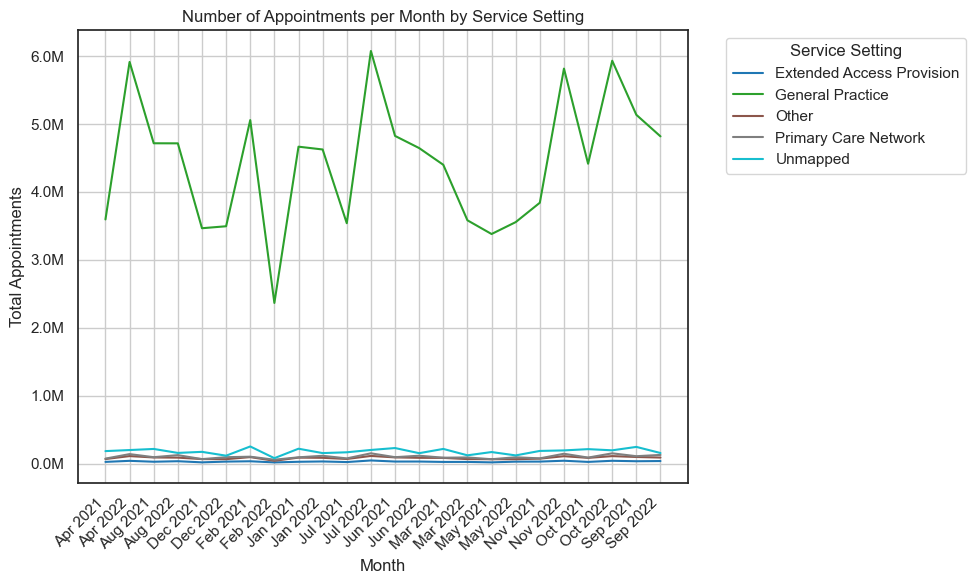

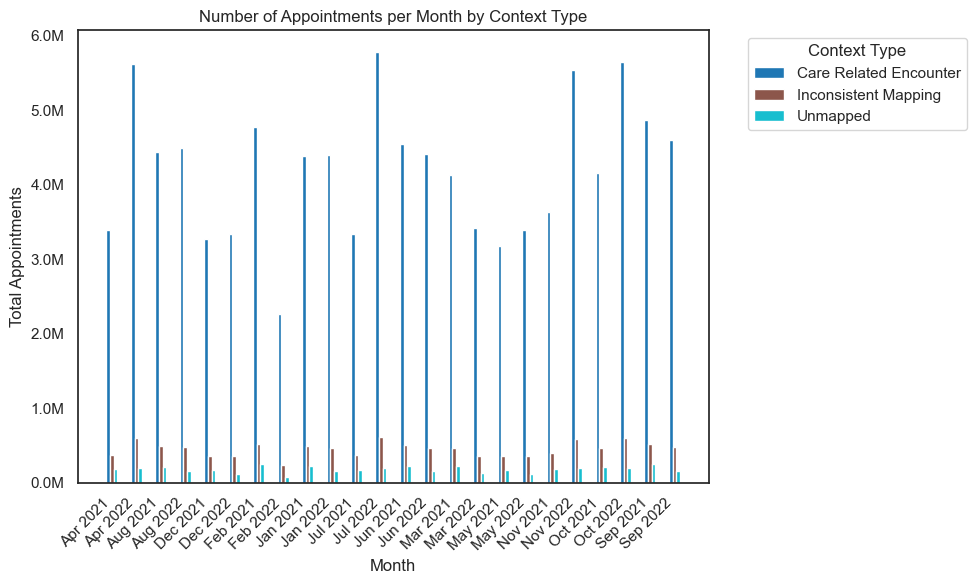

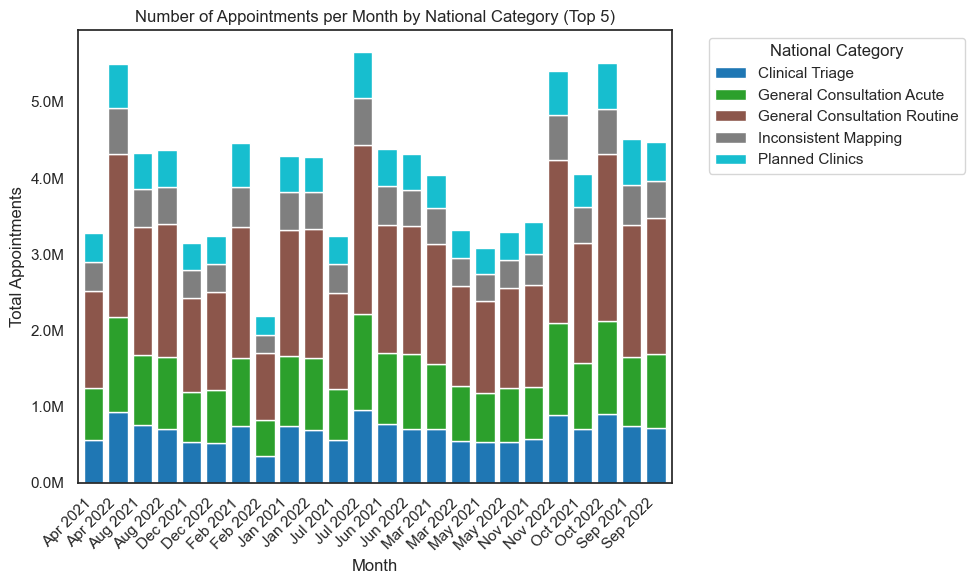

In [24]:
# Charts displaying the number of appointments per month for service settings, context types, and national categories.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Create a month column and format months as names.
nc['appointment_month'] = nc['appointment_date'].dt.to_period('M').dt.to_timestamp()
nc['month_name'] = nc['appointment_month'].dt.strftime('%b %Y')

# 1. Chart - Appointments per month for service settings.
service_settings_monthly = (
    nc.groupby(['month_name', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(service_settings_monthly['service_setting'].unique())))
for color, service in zip(colors, service_settings_monthly['service_setting'].unique()):
    data = service_settings_monthly[service_settings_monthly['service_setting'] == service]
    plt.plot(data['month_name'], data['count_of_appointments'], label=service, color=color)

plt.title('Number of Appointments per Month by Service Setting')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.grid(True)
plt.tight_layout()
plt.savefig("images/service_setting_line.png", dpi=300)
plt.show()

# 2. Chart - Appointments per month for context types.
context_types_monthly = (
    nc.groupby(['month_name', 'context_type'])['count_of_appointments']
    .sum()
    .reset_index()
)

context_pivot = context_types_monthly.pivot(index='month_name', columns='context_type', values='count_of_appointments')
context_pivot = context_pivot.fillna(0)

plt.figure(figsize=(10, 6))
bar_width = 0.15
x = np.arange(len(context_pivot.index))
colors = plt.cm.tab10(np.linspace(0, 1, len(context_pivot.columns)))

for i, (col, color) in enumerate(zip(context_pivot.columns, colors)):
    plt.bar(x + i * bar_width, context_pivot[col], width=bar_width, label=col, color=color)

plt.title('Number of Appointments per Month by Context Type')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(x + bar_width, context_pivot.index, rotation=45, ha='right')
plt.legend(title='Context Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.tight_layout()
plt.savefig("images/context_type_grouped_bar.png", dpi=300)
plt.show()

# 3. Chart - Appointments per month for the top 5 national categories.
category_monthly = (
    nc.groupby(['month_name', 'national_category'])['count_of_appointments']
    .sum()
    .reset_index()
)

top_categories = (
    category_monthly.groupby('national_category')['count_of_appointments']
    .sum()
    .nlargest(5)
    .index
)

category_top5 = category_monthly[category_monthly['national_category'].isin(top_categories)]
category_pivot = category_top5.pivot(index='month_name', columns='national_category', values='count_of_appointments')
category_pivot = category_pivot.fillna(0)

category_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab10',
    width=0.8
)

plt.title('Number of Appointments per Month by National Category (Top 5)')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='National Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.tight_layout()
plt.savefig("images/national_category_stacked.png", dpi=300)
plt.show()

### Seasonal appointment patterns


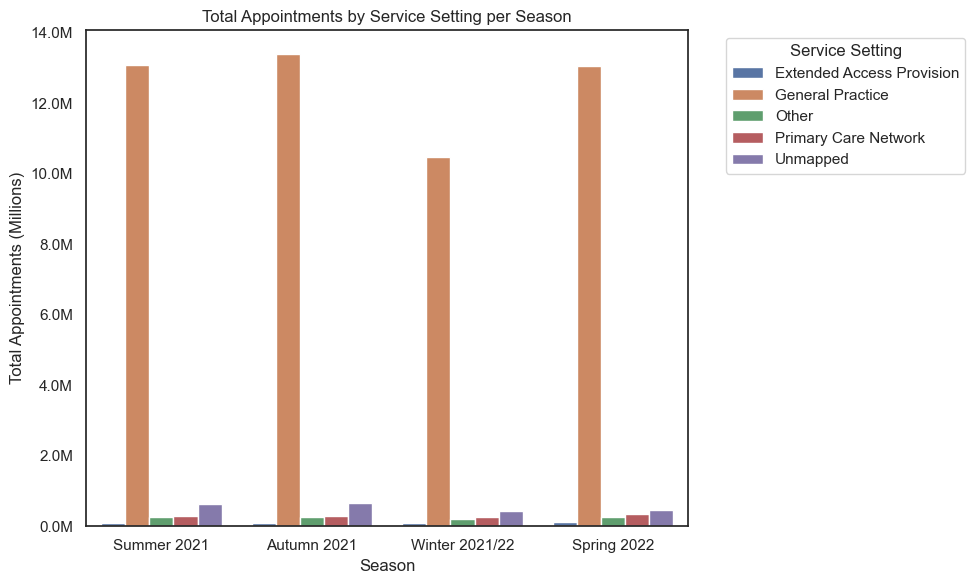

In [25]:
# Combined visualisation: Total appointments by Service Setting per Season.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Appointment_date changed to datetime.
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Define the four seasons.
def get_season(date):
    if pd.Timestamp('2021-06-01') <= date <= pd.Timestamp('2021-08-31'):
        return 'Summer 2021'
    elif pd.Timestamp('2021-09-01') <= date <= pd.Timestamp('2021-11-30'):
        return 'Autumn 2021'
    elif pd.Timestamp('2021-12-01') <= date <= pd.Timestamp('2022-02-28'):
        return 'Winter 2021/22'
    elif pd.Timestamp('2022-03-01') <= date <= pd.Timestamp('2022-05-31'):
        return 'Spring 2022'
    else:
        return None

# Include seasons in the dataset.
nc['season'] = nc['appointment_date'].apply(get_season)

# Group and sum total appointments by season and service setting.
seasonal_summary = (
    nc.groupby(['season', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Ensure seasons are set in chronological order.
seasonal_order = ['Summer 2021', 'Autumn 2021', 'Winter 2021/22', 'Spring 2022']
seasonal_summary['season'] = pd.Categorical(seasonal_summary['season'], categories=seasonal_order, ordered=True)

# Plot the chart.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=seasonal_summary,
    x='season',
    y='count_of_appointments',
    hue='service_setting'
)

# Format y-axis in millions.
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Format chart.
plt.title('Total Appointments by Service Setting per Season')
plt.xlabel('Season')
plt.ylabel('Total Appointments (Millions)')
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("images/service_setting_box.png", dpi=300)
plt.show()
plt.close('all')

# I apologise for the giant white space below the chart, I can't find a fix :(

### Trend summary

**Service setting**  
General Practice appointments dominate monthly activity throughout the period. The pattern persists across the available timeframe, suggesting GP activity is the principal driver of appointment demand.

**Context type**  
Care-related encounters dominate. Recurring `Inconsistent Mapping` and `Unmapped` values indicate data-classification issues that reduce analytical precision.

**National category**  
General Consultation (Acute and Routine) and Clinical Triage account for a large share of appointments, again highlighting the importance of direct-care activity.

**Seasonal comparison**  
General Practice remains dominant across seasons. The available period is relatively short, so stronger claims about seasonality would require a longer time series.


## 4. Social-media analysis


In [26]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [27]:
# Load the data set.
tweets = pd.read_csv("tweets.csv")

# View the DataFrame.
print("Preview of tweets.csv:")
print(tweets.head())

Preview of tweets.csv:
              tweet_id  \
0  1567629223795527681   
1  1567582846612553728   
2  1567582787070304256   
3  1567582767625428992   
4  1567582720460570625   

                                                                                                                                                                                           tweet_full_text  \
0  As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...   
1                                                              RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed.  We're #hiring for…   
2                                                           RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…

In [28]:
# Explore the metadata.
print("Metadata of the data set:\n")

# Summary of the DataFrame
print(tweets.info())

# DataFrame column names
print("\nColumn Names:")
print(tweets.columns.tolist())

# Column data types
print("\nData Types:")
print(tweets.dtypes)

# DataFrame shape
print("\nDataFrame Shape:")
print(tweets.shape)

# Explore the data set with the describe() and info() functions.
# Descriptive stats
print("\nDescriptive statistics of the data set:\n")
print(tweets.describe(include='all'))

Metadata of the data set:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None

Column Names:
['tweet_id', 'tweet_full_text', 'tweet_entities', 'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count', 'tweet_favorite_count', 'tweet_f

In [29]:
# Explore the tweet_retweet_count and tweet_favorite_count columns with the value_counts() function.

# Retweet count.
print("Retweet count frequency:\n")
print(tweets['tweet_retweet_count'].value_counts().sort_index())
print("\n")

# Favourite count.
print("Favourite count frequency:\n")
print(tweets['tweet_favorite_count'].value_counts().sort_index())

Retweet count frequency:

tweet_retweet_count
0      526
1      215
2      114
3       70
4       27
5       35
6       12
7       18
8       15
9       13
10       5
11       6
12      16
13       1
14       1
15       1
16       2
19       1
20       1
23       2
24       2
35      10
37       6
39       1
40       1
41       3
44       4
48       1
49       1
53       5
54       1
57       1
62       3
63       4
68       3
72       2
73      14
76       3
78       2
79       1
85       3
107      1
150      4
169      1
207      3
208     12
303      1
Name: count, dtype: int64


Favourite count frequency:

tweet_favorite_count
0     1027
1       91
2       16
3       13
4        7
5        5
6        2
7        1
8        1
9        1
10       1
11       1
12       1
13       1
14       1
17       1
18       1
20       1
28       1
42       1
Name: count, dtype: int64


### Interpreting engagement metrics

Retweet and favourite counts can be informative, but they require context. High engagement may reflect broad agreement with an experience, but it can also be driven by the reach of an influencer, celebrity or political account.

Engagement data is therefore best treated as supplementary evidence alongside operational and qualitative analysis rather than as a standalone measure of NHS performance.


In [30]:
# Determine whether there are missing values. Only provide detail if so.

missing_values = tweets.isna().sum().sum()

if missing_values > 0:
    print(f"There are {missing_values} missing values in the DataFrame.\n")
    print("Number of missing values per column:\n")
    print(tweets.isna().sum())
else:
    print("There are no missing values in the DataFrame.")

There are 167 missing values in the DataFrame.

Number of missing values per column:

tweet_id                     0
tweet_full_text              0
tweet_entities               0
tweet_entities_hashtags    167
tweet_metadata               0
tweet_retweet_count          0
tweet_favorite_count         0
tweet_favorited              0
tweet_retweeted              0
tweet_lang                   0
dtype: int64


### Retweets and favourites as evidence

Focusing only on highly retweeted or favourited messages would risk excluding useful lower-engagement observations. Individual posts may still contain relevant service insights, particularly when grouped by theme, location or service type.

Social-media evidence should therefore be interpreted carefully and, where possible, validated against internal operational data.


In [31]:
# Create a new DataFrame containing only the tweet text.
tweets_text = tweets[['tweet_full_text']].copy()

# View the DataFrame.
print("Preview of tweet text data:")
print(tweets_text.head())

Preview of tweet text data:
                                                                                                                                                                                           tweet_full_text
0  As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...
1                                                              RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed.  We're #hiring for…
2                                                           RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3                                                             RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect informati

In [32]:
# Loop through the messages, and create a list of values containing the # symbol.
# Create an empty list to store hashtags.
hashtag_list = []

# Loop through each message and extract any words containing '#'.
for tweet in tweets['tweet_full_text']:
    if isinstance(tweet, str):
        hashtags_in_tweet = [word for word in tweet.split() if word.startswith('#')]
        hashtag_list.extend(hashtags_in_tweet)

# Display the first 30 records.
print("Extracted #s:")
print(hashtag_list[:30])

# Check how many #s were extracted.
print(f"\nTotal #s extracted: {len(hashtag_list)}")

Extracted #s:
['#Healthcare', '#PremiseHealth', '#hiring', '#Healthcare', '#blogs', '#digitaltransformation', '#cybersecurity', '#accounting', '#finance', '#healthcare', '#firstcoastcna', '#cnaexam', '#cnaexampreparation', '#jacksonville', '#cnatraining', '#nurse', '#nursing', '#nurselife', '#nursepractitioner', '#nurseproblems', '#nursingschool', '#healthcare', '#disparities.', '#healthcare', '#alert', '#insurance', '#data', '#Healthcare', '#healthcare', '#Healthcare']

Total #s extracted: 4327


In [33]:
# Convert the series to a DataFrame in preparation for visualisation.
hashtags = []  # Empty list to store hashtags

# Loop through each tweet and extract hashtags.
for y in [x.split(' ') for x in tweets['tweet_full_text'].dropna().values]:
    for z in y:
        if '#' in z:
            hashtags.append(z.lower())

# Convert the list to a DataFrame in preparation for visualisation.
hashtags_df = pd.DataFrame(hashtags, columns=['Hashtag'])

# View the DataFrame.
print("Hashtags DataFrame:")
print(hashtags_df.head())

Hashtags DataFrame:
          Hashtag
0     #healthcare
1  #premisehealth
2         #hiring
3     #healthcare
4         🚨#new:🚨


In [34]:
# Fix the count datatype.

# Count occurrences of each hashtag.
hashtag_counts = hashtags_df['Hashtag'].value_counts().reset_index()

# Rename the columns for clarity.
hashtag_counts.columns = ['Hashtag', 'Count']

# Make the count column numeric.
hashtag_counts['Count'] = hashtag_counts['Count'].astype(int)

# View the DataFrame.
print("All hashtags by frequency:\n")
print(hashtag_counts)

All hashtags by frequency:

                                         Hashtag  Count
0                                    #healthcare    716
1                                        #health     80
2                                      #medicine     41
3                                            #ai     40
4                                           #job     38
...                                          ...    ...
1749                               #jacksonville      1
1750                         #cnaexampreparation      1
1751                                    #cnaexam      1
1752  https://t.co/jrgqeqdme4\n.\n#firstcoastcna      1
1753                                 #accounting      1

[1754 rows x 2 columns]


In [35]:
# Display records where the count is larger than 10.
frequently_used_hashtags = hashtag_counts[hashtag_counts['Count'] > 10]

# View the result.
print("Hashtags with a count larger than 10:\n")
print(frequently_used_hashtags)

Hashtags with a count larger than 10:

                        Hashtag  Count
0                   #healthcare    716
1                       #health     80
2                     #medicine     41
3                           #ai     40
4                          #job     38
5                      #medical     35
6                     #strategy     30
7               #pharmaceutical     28
8                       #pharma     25
9                    #marketing     25
10               #digitalhealth     25
11                  #medtwitter     24
12                     #biotech     24
13     #competitiveintelligence     24
14                       #meded     23
15                      #hiring     18
16                     #vaccine     18
17                  #technology     17
18             #machinelearning     17
19                        #news     17
20        #competitivemarketing     16
21                 #coronavirus     16
22                       #covid     16
23             #womeninme

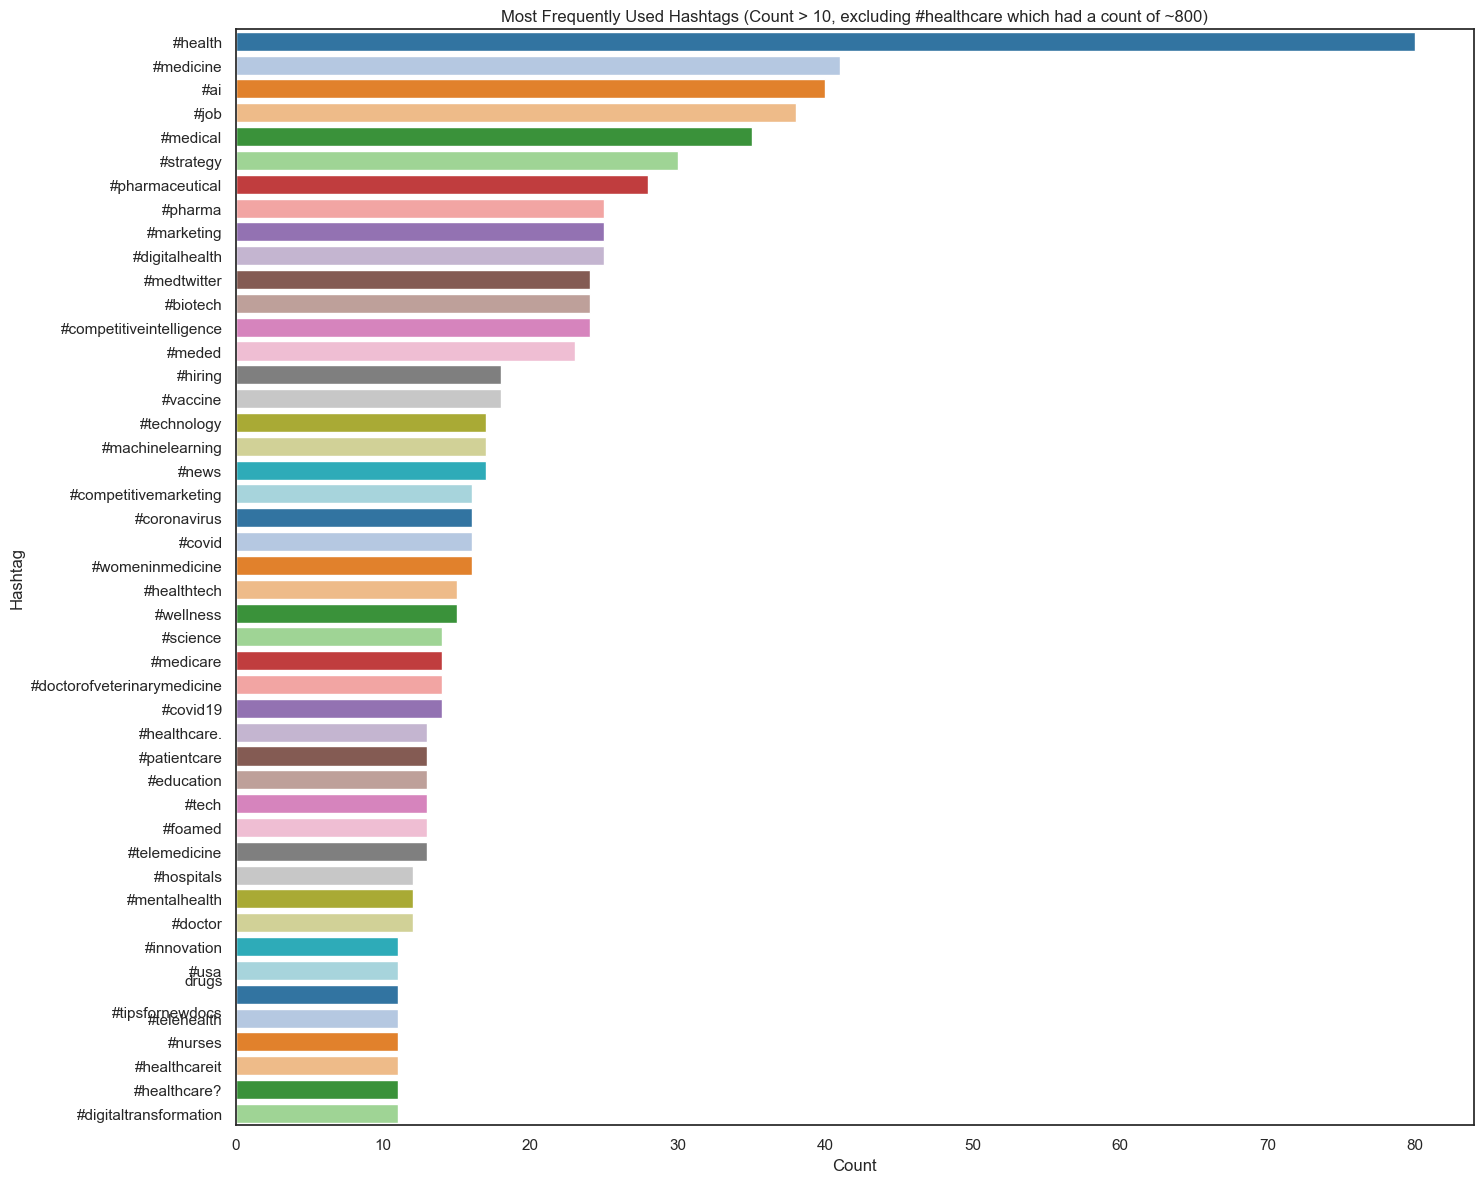

In [36]:
# Create a Seaborn barplot indicating records with a count >10 records (case-insensitive),
# excluding overrepresented hashtags such as #healthcare for better visual balance.

import seaborn as sns
import matplotlib.pyplot as plt

# Convert all hashtags to lowercase to ignore capitalisation.
hashtags_df['Hashtag'] = hashtags_df['Hashtag'].str.lower()

# Count occurrences of each hashtag.
hashtag_counts = hashtags_df['Hashtag'].value_counts().reset_index()

# Rename the columns.
hashtag_counts.columns = ['Hashtag', 'Count']

# Remove the overrepresented hashtag '#healthcare' for clearer visualisation.
hashtag_counts = hashtag_counts[hashtag_counts['Hashtag'] != '#healthcare']

# Filter hashtags with a count >10 records and ensure descending order.
frequently_used_hashtags = hashtag_counts[hashtag_counts['Count'] > 10]
frequently_used_hashtags = frequently_used_hashtags.sort_values(by='Count', ascending=False)

# Build the chart.
plt.figure(figsize=(15, 12))
sns.barplot(data=frequently_used_hashtags, x='Count', y='Hashtag', palette='tab20')

# Format the chart.
plt.title('Most Frequently Used Hashtags (Count > 10, excluding #healthcare which had a count of ~800)')
plt.xlabel('Count')
plt.ylabel('Hashtag')
plt.tight_layout()
plt.savefig("images/hashtag_bar.png", dpi=300)
plt.show()

### Stakeholder application

Social-media data can help identify emerging themes in public discussion and provide additional context to internal service data. Potential uses include:

- monitoring changes in public sentiment over time;
- identifying frequently reported pain points;
- comparing public discussion with operational measures such as waiting times or service demand;
- using targeted hashtags and keywords to improve monitoring;
- incorporating location and time information where available;
- filtering likely spam, bot or irrelevant content.

The data should be treated as supplementary rather than definitive evidence of service performance.


### Social-media observations

General healthcare discussion was common in the supplied data, but direct discussion of the NHS was relatively limited. More targeted collection using NHS-specific hashtags, keywords, dates and location information would improve the usefulness of this source.

The visualisation was refined for clarity and accessibility using a colour-blind-friendly palette and adjusted scaling.


## 5. Operational performance analysis


In [37]:
# Prepare your workstation.
import pandas as pd

# Load the appointments_regional.csv file.
ar = pd.read_csv("appointments_regional.csv")

# View the DataFrame.
print("Preview of appointments_regional.csv:")
print(ar.head())

Preview of appointments_regional.csv:
  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034           2020-01           Attended       GP     Face-to-Face   
1    E54000034           2020-01           Attended       GP     Face-to-Face   
2    E54000034           2020-01           Attended       GP     Face-to-Face   
3    E54000034           2020-01           Attended       GP     Face-to-Face   
4    E54000034           2020-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                   8107  
1                    15  to 21 Days                   6791  
2                       2 to 7 Days                  20686  
3                    22  to 28 Days                   4268  
4                     8  to 14 Days                  11971  


In [38]:
# Print the min and max dates.

# Change appointment_month column to datetime.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], format='%Y-%m', errors='coerce')

# View the DataFrame.
print("Earliest appointment month:", ar['appointment_month'].min().strftime('%d-%m-%Y'))
print("Latest appointment month:", ar['appointment_month'].max().strftime('%d-%m-%Y'))

Earliest appointment month: 01-01-2020
Latest appointment month: 01-06-2022


In [39]:
# Filter the data set to only look at data from 2021-08 onwards.

# Change appointment_month column to datetime.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], format='%Y-%m', errors='coerce')

# Filter the data.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# View the filtered data.
print("Preview of filtered data (from 2021-08 onwards):")
print(ar_filtered.head())

# Confirm the new date range.
print("\nFiltered date range:")
print("Earliest:", ar_filtered['appointment_month'].min().strftime('%d-%m-%Y'))
print("Latest:", ar_filtered['appointment_month'].max().strftime('%d-%m-%Y'))

Preview of filtered data (from 2021-08 onwards):
     icb_ons_code appointment_month appointment_status hcp_type  \
3652    E54000034        2021-08-01           Attended       GP   
3653    E54000034        2021-08-01           Attended       GP   
3654    E54000034        2021-08-01           Attended       GP   
3655    E54000034        2021-08-01           Attended       GP   
3656    E54000034        2021-08-01           Attended       GP   

     appointment_mode time_between_book_and_appointment  count_of_appointments  
3652     Face-to-Face                             1 Day                   6553  
3653     Face-to-Face                    15  to 21 Days                   2390  
3654     Face-to-Face                       2 to 7 Days                  10547  
3655     Face-to-Face                    22  to 28 Days                    937  
3656     Face-to-Face                     8  to 14 Days                   4961  

Filtered date range:
Earliest: 01-08-2021
Latest: 01-06-2022


### Capacity and staffing


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Create an aggregated data set to review the different features (appointments_regional).
ar_agg = (
    ar.groupby(
        ['appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode', 'time_between_book_and_appointment']
    )['count_of_appointments']
    .sum()
    .reset_index()
)    
# View the DataFrame.
print("Aggregated DataFrame (ar_agg) preview:")
print(ar_agg.head())


Aggregated DataFrame (ar_agg) preview:
  appointment_month hcp_type appointment_status appointment_mode  \
0        2020-01-01       GP           Attended     Face-to-Face   
1        2020-01-01       GP           Attended     Face-to-Face   
2        2020-01-01       GP           Attended     Face-to-Face   
3        2020-01-01       GP           Attended     Face-to-Face   
4        2020-01-01       GP           Attended     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                 653846  
1                    15  to 21 Days                 620789  
2                       2 to 7 Days                1723834  
3                    22  to 28 Days                 421189  
4                     8  to 14 Days                1123186  


In [41]:
# Group by month and calculate total monthly appointments.
ar_df = (
    ar.groupby('appointment_month')['count_of_appointments']
    .sum()
    .reset_index()
)

# Add a new column for average daily utilisation (monthly total ÷ 30 days).
ar_df['utilisation'] = (ar_df['count_of_appointments'] / 30).round(1)

# NHS benchmark capacity: 1.2 million appointments per day.
nhs_capacity = 1_200_000

print("\nMonthly totals and average daily utilisation:")
print(ar_df.head())


Monthly totals and average daily utilisation:
  appointment_month  count_of_appointments  utilisation
0        2020-01-01               27199296     906643.2
1        2020-02-01               24104621     803487.4
2        2020-03-01               24053468     801782.3
3        2020-04-01               16007881     533596.0
4        2020-05-01               16417212     547240.4


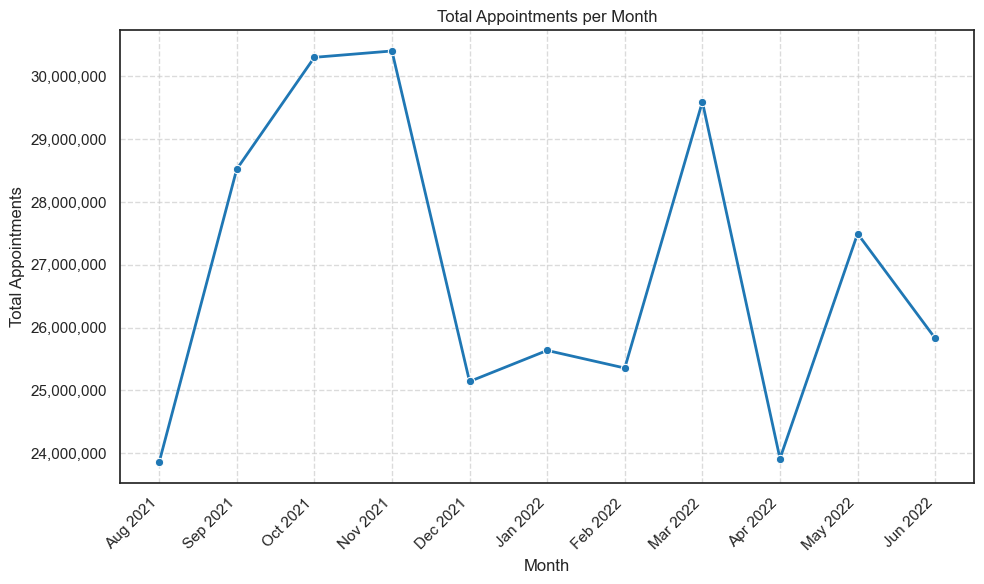

In [42]:
# Plot sum of count of monthly visits.
ar_agg['appointment_month'] = pd.to_datetime(ar_agg['appointment_month'], errors='coerce')
ar_df['appointment_month'] = pd.to_datetime(ar_df['appointment_month'], errors='coerce')

# Filter from August 2021 onwards for consistency.
ar_agg = ar_agg[ar_agg['appointment_month'] >= '2021-08-01']
ar_df = ar_df[ar_df['appointment_month'] >= '2021-08-01']

# Format months as readable labels (e.g. "Aug 2021").
ar_df['appointment_month'] = ar_df['appointment_month'].dt.strftime('%b %Y')
ar_agg['appointment_month'] = ar_agg['appointment_month'].dt.strftime('%b %Y')

# 4. Plot 1: Number of monthly visits.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=ar_df,
    x='appointment_month',
    y='count_of_appointments',
    marker='o',
    linewidth=2,
    color='tab:blue'
)

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Total Appointments per Month')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/monthly_total_line.png", dpi=300)
plt.show()


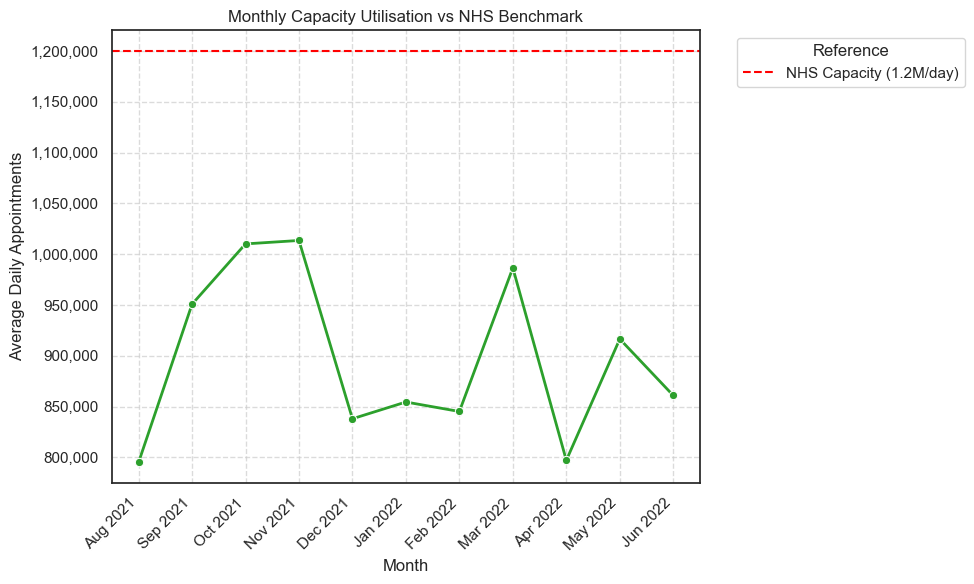

In [43]:
# Plot the monthly capacity utilisation (average daily appointments).

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=ar_df,
    x='appointment_month',
    y='utilisation',
    marker='o',
    linewidth=2,
    color='tab:green'
)

# Add NHS benchmark capacity line.
plt.axhline(y=nhs_capacity, color='red', linestyle='--', linewidth=1.5, label='NHS Capacity (1.2M/day)')

# Format y-axis for readability.
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Format the chart.
plt.title('Monthly Capacity Utilisation vs NHS Benchmark')
plt.xlabel('Month')
plt.ylabel('Average Daily Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reference', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/utilisation_line.png", dpi=300)
plt.show()

### Healthcare professional mix


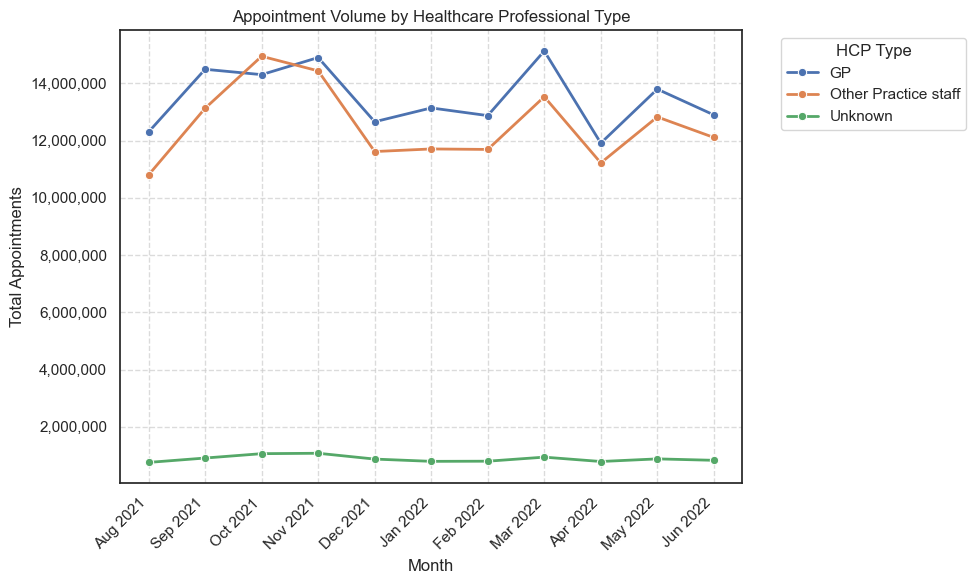

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ensure appointment_month is in datetime format.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], errors='coerce')

# Filter data from August 2021 onwards.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# Group by month and healthcare professional (HCP) type, summing total appointments.
hcp_trends = (
    ar_filtered.groupby(['appointment_month', 'hcp_type'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Convert month to readable labels (e.g. 'Aug 2021').
hcp_trends['appointment_month'] = hcp_trends['appointment_month'].dt.strftime('%b %Y')

# Create the lineplot.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=hcp_trends,
    x='appointment_month',
    y='count_of_appointments',
    hue='hcp_type',
    marker='o',
    linewidth=2
)

# Format the y-axis for readability (no scientific notation).
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Format and label the chart.
plt.title('Appointment Volume by Healthcare Professional Type')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='HCP Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/hcp_line.png", dpi=300)
plt.show()

### Appointment attendance


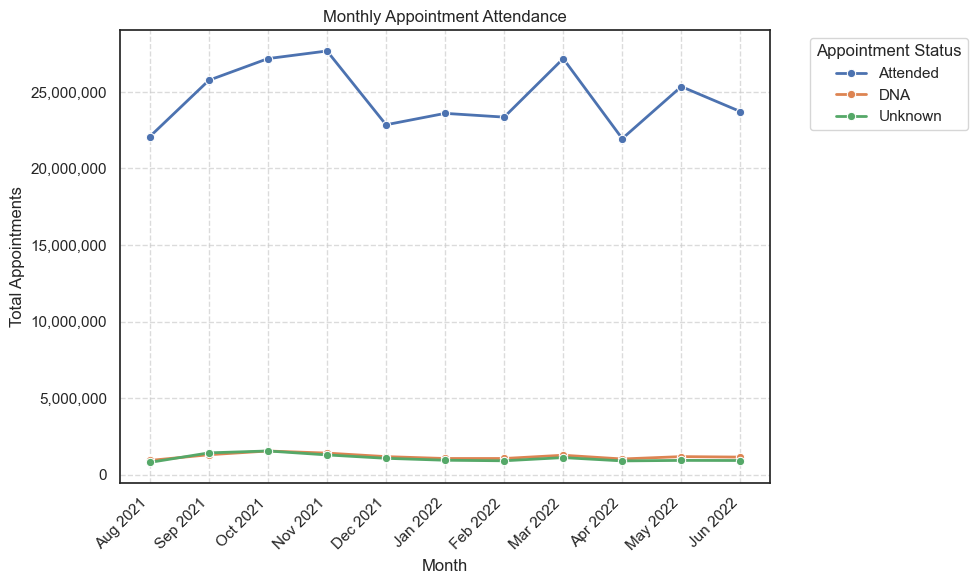

In [45]:
# Create a line plot to visualise trends in appointment attendance over time (Aug 2021 onwards).

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ensure appointment_month is in datetime format.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], errors='coerce')

# Filter data from August 2021 onwards.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# Group by month and appointment status, summing total appointments.
attendance_trends = (
    ar_filtered.groupby(['appointment_month', 'appointment_status'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Convert month to readable labels (e.g. 'Aug 2021').
attendance_trends['appointment_month'] = attendance_trends['appointment_month'].dt.strftime('%b %Y')

# Create the lineplot.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=attendance_trends,
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_status',
    marker='o',
    linewidth=2
)

# Format y-axis as plain numbers (no scientific notation).
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Format and label the chart.
plt.title('Monthly Appointment Attendance')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Appointment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/attendance_line.png", dpi=300)
plt.show()

### Appointment mode


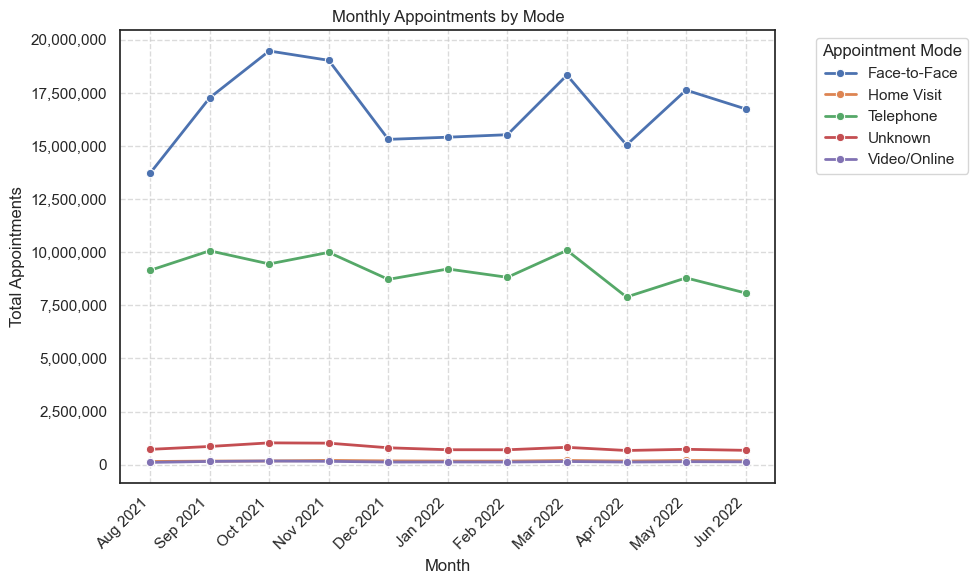

In [46]:
# Create a line plot to visualise trends in appointment types over time (Aug 2021 onwards).

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ensure appointment_month is in datetime format.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], errors='coerce')

# Filter data from August 2021 onwards.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# Group by month and appointment mode, summing total appointments.
appointment_type_trends = (
    ar_filtered.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Convert month to readable labels (e.g. 'Aug 2021').
appointment_type_trends['appointment_month'] = appointment_type_trends['appointment_month'].dt.strftime('%b %Y')

# Create the lineplot.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=appointment_type_trends,
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_mode',
    marker='o',
    linewidth=2
)

# Format y-axis as plain numbers (no scientific notation).
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Format and label the chart.
plt.title('Monthly Appointments by Mode')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Appointment Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/mode_line.png", dpi=300)
plt.show()

### Booking-to-appointment intervals


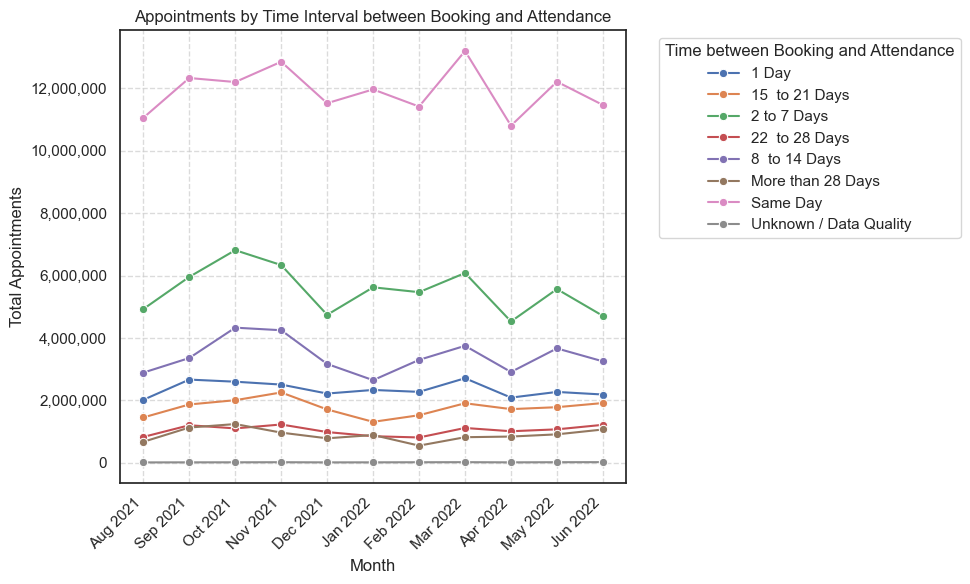

In [47]:
# Create a line plot to visualise trends in time between booking and appointment (Aug 2021 onwards).

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ensure appointment_month is in datetime format.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], format='%Y-%m', errors='coerce')

# Filter the dataset to only include data from August 2021 onwards.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# Group by month and time between booking and appointment, summing total appointments.
booking_gap_trends = (
    ar_filtered.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Convert months to readable format (e.g. 'Aug 2021').
booking_gap_trends['appointment_month'] = booking_gap_trends['appointment_month'].dt.strftime('%b %Y')

# Create the line plot.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=booking_gap_trends,
    x='appointment_month',
    y='count_of_appointments',
    hue='time_between_book_and_appointment',
    marker='o'
)

# Format y-axis as plain numbers with commas (no scientific notation).
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Style and label the chart.
plt.title('Appointments by Time Interval between Booking and Attendance')
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time between Booking and Attendance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/booking_line.png", dpi=300)
plt.show()

### Service-setting comparison


Preview of service settings data:
  appointment_month            service_setting  count_of_appointments
0          Aug 2021  Extended Access Provision                  32962
1          Aug 2021           General Practice                4716540
2          Aug 2021                      Other                  95774
3          Aug 2021       Primary Care Network                  99874
4          Aug 2021                   Unmapped                 221021


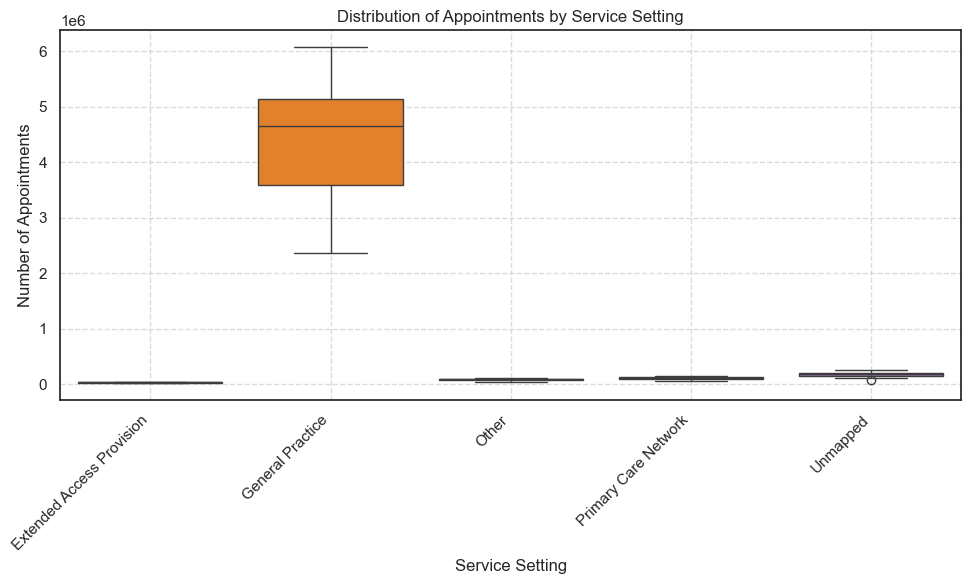

In [48]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure appointment_date is in datetime format.
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Filter data to only include appointments from August 2021 onwards.
nc_filtered = nc[nc['appointment_date'] >= '2021-08-01']

# Create a new DataFrame with the month of appointment and the number of appointments.
service_setting_df = (
    nc_filtered.groupby(['appointment_month', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Convert month to readable format (e.g. 'Aug 2021').
service_setting_df['appointment_month'] = pd.to_datetime(service_setting_df['appointment_month'], errors='coerce')
service_setting_df['appointment_month'] = service_setting_df['appointment_month'].dt.strftime('%b %Y')

# View the new DataFrame.
print("Preview of service settings data:")
print(service_setting_df.head())

# Create a boxplot to visualise variation in number of appointments by service setting.
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=service_setting_df,
    x='service_setting',
    y='count_of_appointments',
    palette='tab10'
)

# Style and label the chart.
plt.title('Distribution of Appointments by Service Setting')
plt.xlabel('Service Setting')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/service_setting_boxplot.png", dpi=300)
plt.show()


Preview of service settings data (excluding GP visits):
  appointment_month            service_setting  count_of_appointments
0          Aug 2021  Extended Access Provision                  32962
2          Aug 2021                      Other                  95774
3          Aug 2021       Primary Care Network                  99874
4          Aug 2021                   Unmapped                 221021
5          Sep 2021  Extended Access Provision                  40257


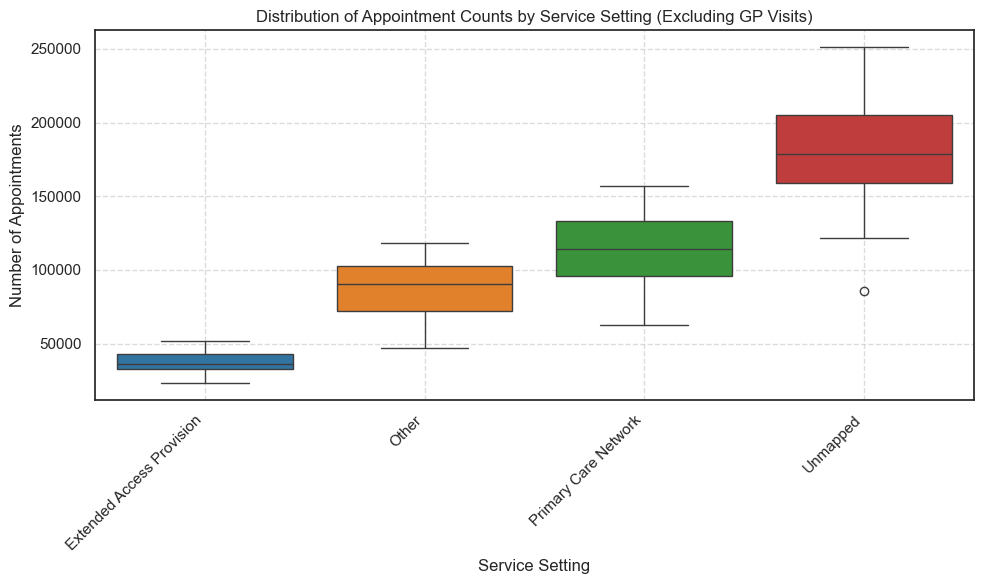

In [49]:
# Create a boxplot in Seaborn focusing on all service settings, excluding GP visits (Aug 2021 onwards).

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure appointment_date is in datetime format.
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Filter to only include appointments from August 2021 onwards.
nc_filtered = nc[nc['appointment_date'] >= '2021-08-01']

# Create a new DataFrame with the month of appointment and the number of appointments.
service_setting_df = (
    nc_filtered.groupby(['appointment_month', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Exclude GP visits.
service_setting_df = service_setting_df[service_setting_df['service_setting'] != 'General Practice']

# Convert month to readable format (e.g. 'Aug 2021').
service_setting_df['appointment_month'] = pd.to_datetime(service_setting_df['appointment_month'], errors='coerce')
service_setting_df['appointment_month'] = service_setting_df['appointment_month'].dt.strftime('%b %Y')

# View the DataFrame.
print("Preview of service settings data (excluding GP visits):")
print(service_setting_df.head())

# Create a boxplot visualising the distribution of appointments for each service setting.
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=service_setting_df,
    x='service_setting',
    y='count_of_appointments',
    palette='tab10'
)

# Style and label the chart.
plt.title('Distribution of Appointment Counts by Service Setting (Excluding GP Visits)')
plt.xlabel('Service Setting')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/service_setting_boxplot_2.png", dpi=300)
plt.show()

## 6. Findings and recommendations


### Findings

- Total monthly appointments during the analysed period were approximately 24–31 million.
- Average daily appointments were approximately 800,000 to just over 1 million against the supplied 1.2 million daily capacity benchmark.
- GP and other practice-staff appointment volumes followed broadly similar patterns.
- The large majority of appointments were attended, but around one million appointments were missed each month, representing a persistent operational inefficiency.
- Face-to-face appointments were the dominant appointment mode, followed by telephone appointments.
- Same-day appointments accounted for the largest share of bookings, while appointments booked more than a month in advance represented the smallest share.
- The available timeframe is too short to draw strong conclusions about long-term seasonality.

### Recommendations

**General Practice**
- Focus further analysis and targeted investment on high-demand areas, including staffing, extended hours and operational-efficiency measures.

**Missed appointments**
- Strengthen reminder systems, simplify cancellations and expand appropriate alternative appointment modes to reduce avoidable capacity loss.

**Social-media monitoring**
- Use targeted NHS-specific hashtags and keywords, combined with time and location information, as a supplementary early-warning source for emerging service issues.
- Validate social-media signals against internal operational data before using them in decision-making.

### Limitations

The supplied data did not allow staffing adequacy to be measured directly, so staffing conclusions should not be inferred solely from appointment utilisation. A longer time series would also be required to assess seasonality and structural demand changes more reliably.


## Accessibility

Charts were designed with colour-vision accessibility in mind, using the Tab10 and Tab20 palettes where appropriate.
